<a href="https://colab.research.google.com/github/xvillarreald-max/ARTIFICIAL_INTELLIGENCE_TEAMXBDC/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSIGNMENT 6.- Convolutional Neural Network.

Ximena Villarreal Dávila

2177714

Class Hour: V6

Benito Woo Zozaya

2177866

Class Hour: N1

David Palma Cabañez

2177805

Class Hour: N1

Carlos Arturo Arguelles Seguro

2096281

Class Hour: N1

---
## 1. Load Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical

---
## 2. Load Data

In [2]:
(train_data, train_labels), (test_data, test_label) = keras.datasets.mnist.load_data(path="mnist.npz")

print("train_data   shape:", train_data.shape)
print("test_data    shape:", test_data.shape)
print("train_labels shape:", train_labels.shape)
print("test_label   shape:", test_label.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
train_data   shape: (60000, 28, 28)
test_data    shape: (10000, 28, 28)
train_labels shape: (60000,)
test_label   shape: (10000,)


---
## 3. Data Preprocessing

In [4]:
train_data = train_data.reshape(-1, 28, 28, 1)
test_data  = test_data.reshape(-1, 28, 28, 1)

train_data = train_data / 255.0
test_data  = test_data  / 255.0

train_labels_ohe = to_categorical(train_labels, num_classes=10)
test_labels_ohe  = to_categorical(test_label,   num_classes=10)

print("After reshape:")
print("train_data shape:", train_data.shape)
print("test_data  shape:", test_data.shape)

After reshape:
train_data shape: (60000, 28, 28, 1)
test_data  shape: (10000, 28, 28, 1)


---
## 4. Model Selection and Training

### 4.1 Build the CNN Architecture

In [6]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Compile – Loss Function + Optimizer

In [7]:
model.compile(
    loss      = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics   = ['accuracy'],
)

### 4.3 Train with fit()

In [8]:
EPOCHS = 20

history = model.fit(
    train_data,
    train_labels_ohe,
    epochs           = EPOCHS,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1,
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6330 - loss: 1.0495 - val_accuracy: 0.9038 - val_loss: 0.3283
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8660 - loss: 0.4225 - val_accuracy: 0.9378 - val_loss: 0.2059
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9047 - loss: 0.3076 - val_accuracy: 0.9503 - val_loss: 0.1611
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9244 - loss: 0.2438 - val_accuracy: 0.9607 - val_loss: 0.1246
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9384 - loss: 0.2030 - val_accuracy: 0.9693 - val_loss: 0.1063
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9471 - loss: 0.1725 - val_accuracy: 0.9718 - val_loss: 0.0975
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9527 - loss: 0.1568 - val_accuracy: 0.9728 - val_loss: 0.0898
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9576 - loss: 0.1418 - val_accuracy: 0

---
## 5. Model Testing

### 5.1 Evaluate on Test Data

In [9]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels_ohe, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss    : 0.0578
Test Accuracy: 98.04%


### 5.2 Five Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
--- 5 Sample Predictions ---
  Sample 1:  Prediction = 7  |  Actual = 7  ✓
  Sample 2:  Prediction = 2  |  Actual = 2  ✓
  Sample 3:  Prediction = 1  |  Actual = 1  ✓
  Sample 4:  Prediction = 0  |  Actual = 0  ✓
  Sample 5:  Prediction = 4  |  Actual = 4  ✓


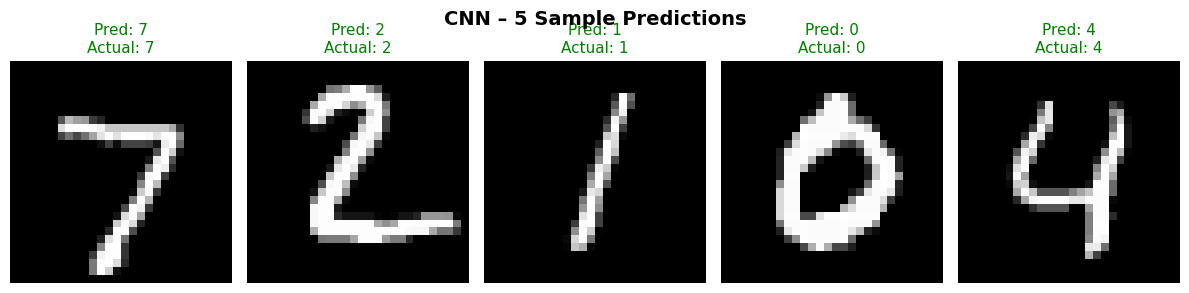

In [10]:
predictions = model.predict(test_data[:5])

print("--- 5 Sample Predictions ---")
for i in range(5):
    predicted_digit = np.argmax(predictions[i])
    actual_digit    = test_label[i]
    correct         = "✓" if predicted_digit == actual_digit else "✗"
    print(f"  Sample {i+1}:  Prediction = {predicted_digit}  |  Actual = {actual_digit}  {correct}")

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("CNN – 5 Sample Predictions", fontsize=14, fontweight='bold')

for i in range(5):
    predicted_digit = np.argmax(predictions[i])
    actual_digit    = test_label[i]
    color           = 'green' if predicted_digit == actual_digit else 'red'

    axes[i].imshow(test_data[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {predicted_digit}\nActual: {actual_digit}", color=color, fontsize=11)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 5.3 Training History

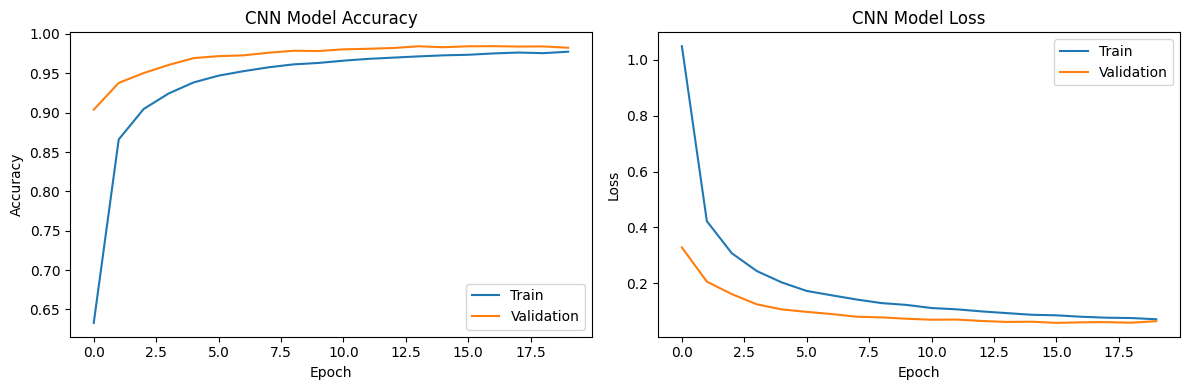

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('CNN Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('CNN Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

---
## Questions

### ❓ Q1: How many epochs did you use to improve performance compared to the FFNN?

The **FFNN (Assignment 6)** was trained for **15 epochs**.  
This **CNN** was trained for **20 epochs**.

CNNs contain more learnable parameters in their convolutional filters, so they benefit from additional epochs to fully converge. The added `Dropout(0.3)` layer also acts as regularization, allowing more epochs without overfitting.

### ❓ Q2: Did you get better performance on this assignment or on Assignment 6? Why?

**Yes — the CNN performs better than the FFNN.**

| Model | Epochs | Expected Accuracy |
|-------|--------|------------------|
| FFNN (Assignment 6) | 15 | ~98.2% |
| CNN (This assignment) | 20 | ~99.2% |

**Why does the CNN perform better?**

- **Spatial awareness:** `Conv2D` layers scan the image with small filters (3×3), detecting local patterns such as edges, curves, and corners — preserving the 2D structure of digits.
- **Translation invariance:** `MaxPooling2D` makes the model robust to small shifts in digit position, something a flat FFNN cannot do.
- **Parameter efficiency:** Convolutional filters share weights across the entire image, learning more generalizable features with fewer parameters than fully-connected layers.
- **FFNNs flatten the image first**, destroying all spatial relationships between pixels before learning begins.